<a href="https://colab.research.google.com/github/chizkidd/transformers-from-scratch/blob/main/bert-sst2-sentiment-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transformer Models: A collection of various transformer architectures, models, & their implementations-from-scratch (`PyTorch`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/transformers-from-scratch
---

In [1]:
%%capture
!pip install watermark
!pip install torchinfo
!pip install datasets


In [2]:
%load_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch


Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 7.34.0

torch: 2.10.0+cu128



# BERT: Pre-training of Deep Bidirectional Transformers
---



This notebook implements **BERT** (Bidirectional Encoder Representations from Transformers) **[1]** from scratch,
evolving directly from the Transformer Encoder in the previous *"Attention Is All You Need"* notebook.

The implementation has **two phases:**

1. **Phase 1 — Pre-training:** We train BERT with two self-supervised objectives:
   - **Masked Language Modeling (MLM):** Randomly mask 15% of tokens and predict them.
   - **Next Sentence Prediction (NSP):** Given two sentences, predict if sentence B actually follows sentence A.

2. **Phase 2 — Fine-tuning:** We take the pre-trained BERT and add a classification head to fine-tune on
   **SST-2** (Stanford Sentiment Treebank, GLUE benchmark) for binary sentiment analysis.

<br>

## BERT: Pre-Training & Fine-Tuning
![BERT](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*5cQlEV_7WuzUfE1B__jR5Q.png)

<br>

### Key Differences: Transformer (Encoder-Decoder) → BERT (Encoder-Only)

| Feature | Original Transformer | BERT |
| :--- | :--- | :--- |
| **Architecture** | Encoder + Decoder | **Encoder only** |
| **Attention** | Causal (masked future) in Decoder | **Bidirectional** (sees full context) |
| **Position Embeddings** | Sinusoidal (fixed) | **Learned** |
| **Segment Embeddings** | None | **Yes** (Sentence A vs B for NSP) |
| **Activation** | ReLU | **GELU** |
| **Special Tokens** | `<SOS>`, `<EOS>` | **`[CLS]`, `[SEP]`, `[MASK]`, `[PAD]`** |
| **Pre-training** | Supervised (translation) | **Self-supervised** (MLM + NSP) |
| **Primary Metric** | BLEU | **Accuracy** (on downstream tasks) |

<br>

### BERT Language Understanding Tasks

$$\text{MLM: } P(x_i \mid x_{\backslash i}) \quad \text{(predict masked token from bidirectional context)}$$

$$\text{NSP: } P(\text{IsNext} \mid [\texttt{CLS}]) \quad \text{(binary classification from [CLS] embedding)}$$
<br>

| Task | Details |
| :--- | :--- |
| $$\text{MLM: } P(x_i \mid x_{\backslash i})$$ |  $\text{(predict masked token from bidirectional context)}$ |
| $$\text{NSP: } P(\text{IsNext} \mid [\texttt{CLS}])$$ | $$\text{(binary classification from [CLS] embedding)}$$ |



<br>

---

**REFERENCES:**

1. Devlin, Jacob, et al. ["BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding."](https://arxiv.org/abs/1810.04805) *NAACL*, 2019.
2. Vaswani, Ashish, et al. ["Attention is all you need."](https://arxiv.org/abs/1706.03762) *NeurIPS*, 2017.
3. Wang, Alex, et al. ["GLUE: A Multi-Task Benchmark."](https://arxiv.org/abs/1804.07461) *ICLR*, 2019.

---


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True


In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


---
# 0. Hyperparameters
---


In [5]:
##########################
### SETTINGS
##########################

RANDOM_SEED = 123
set_all_seeds(RANDOM_SEED)

# Vocabulary
VOCABULARY_SIZE = 10000

# BERT Architecture (BERT-Small for training feasibility)
D_MODEL = 768 # 256 # 768
N_LAYERS = 12 # 4 # 12
N_HEADS = 12 # 8 # 12
D_FF = 4 * D_MODEL # 4 * 768
DROPOUT = 0.1
MAX_LEN = 128

# Pre-training
PRETRAIN_EPOCHS = 10
PRETRAIN_BATCH_SIZE = 64
PRETRAIN_LR = 1e-4

# Fine-tuning
FINETUNE_EPOCHS = 10
FINETUNE_BATCH_SIZE = 32
FINETUNE_LR = 2e-5
PATIENCE = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


---
# 1. Data Preparation & Vocabulary

We build a single vocabulary from **WikiText-2** for pre-training,
then reuse it for SST-2 fine-tuning.

---


In [6]:
# ==========================================
# 1a. Load Datasets
# ==========================================

# Pre-training corpus
wiki_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Fine-tuning dataset (SST-2 from GLUE)
sst2_dataset = load_dataset("glue", "sst2")

print(f"WikiText-2 samples - train: {len(wiki_dataset['train'])}, val: {len(wiki_dataset['validation'])}, test: {len(wiki_dataset['test'])}")
print(f"SST-2 samples - train: {len(sst2_dataset['train'])}, val: {len(sst2_dataset['validation'])}, test: {len(sst2_dataset['test'])}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

WikiText-2 samples - train: 36718, val: 3760, test: 4358
SST-2 samples - train: 67349, val: 872, test: 1821


In [7]:
# ==========================================
# 1b. Tokenizer & Vocabulary
# ==========================================

def tokenizer(text):
    """Simple word-level tokenizer with punctuation splitting."""
    return re.findall(r"[\w']+|[.,!?;:\-]", text.lower())

# BERT Special Tokens
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
PAD_IDX, UNK_IDX, CLS_IDX, SEP_IDX, MASK_IDX = 0, 1, 2, 3, 4

# Build vocab from WikiText-2 (the pre-training corpus)
word_counts = Counter()
for item in wiki_dataset['train']:
    text = item['text'].strip()
    if len(text) > 0:
        word_counts.update(tokenizer(text))

# Build vocab dict
vocab = {word: i for i, word in enumerate(SPECIAL_TOKENS)}
for word, _ in word_counts.most_common(VOCABULARY_SIZE - len(SPECIAL_TOKENS)):
    if word not in vocab:
        vocab[word] = len(vocab)

inv_vocab = {v: k for k, v in vocab.items()}

ACTUAL_VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {ACTUAL_VOCAB_SIZE}")
print(f"Sample tokens: {list(vocab.keys())[:15]}")


Vocabulary size: 10000
Sample tokens: ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]', 'the', ',', '.', 'of', 'and', 'in', 'to', 'a', 'was', '-']


---
# 1. Pre-training Data Pipeline (MLM + NSP)

For **NSP**, we construct sentence pairs:
- 50% of the time, sentence B actually follows sentence A (`IsNext = 1`)
- 50% of the time, sentence B is a random sentence (`NotNext = 0`)

For **MLM**, we mask 15% of the input tokens in each pair:
- 80% → replaced with `[MASK]`
- 10% → replaced with a random token
- 10% → kept unchanged

---


In [8]:
# ==========================================
# 1c. Pre-training Dataset (MLM + NSP)
# ==========================================

def encode_sentence(text, max_len=None):
    """Tokenize and convert to indices."""
    tokens = tokenizer(text)
    if max_len is not None:
        tokens = tokens[:max_len]
    return [vocab.get(t, UNK_IDX) for t in tokens]


class BERTPretrainDataset(Dataset):
    """
    Constructs MLM + NSP training pairs from raw text.
    Each sample: ([CLS] sent_A [SEP] sent_B [SEP], segment_ids, mlm_labels, nsp_label)
    """
    def __init__(self, text_dataset, vocab, max_len=128, mlm_prob=0.15):
        super().__init__()
        self.max_len = max_len
        self.mlm_prob = mlm_prob
        self.vocab = vocab
        self.vocab_size = len(vocab)

        # Collect non-empty sentences
        self.sentences = []
        for item in text_dataset:
            text = item['text'].strip()
            if len(text) > 10:  # Skip very short/empty lines
                self.sentences.append(text)

        print(f"  PretrainDataset: {len(self.sentences)} sentences loaded.")

    def __len__(self):
        return len(self.sentences) - 1  # Need pairs

    def __getitem__(self, idx):
        # --- NSP: 50% real next, 50% random ---
        sent_a = encode_sentence(self.sentences[idx], max_len=self.max_len // 2 - 2)

        if random.random() > 0.5 and idx + 1 < len(self.sentences):
            sent_b = encode_sentence(self.sentences[idx + 1], max_len=self.max_len // 2 - 1)
            nsp_label = 1  # IsNext
        else:
            rand_idx = random.randint(0, len(self.sentences) - 1)
            sent_b = encode_sentence(self.sentences[rand_idx], max_len=self.max_len // 2 - 1)
            nsp_label = 0  # NotNext

        # --- Build BERT input: [CLS] A [SEP] B [SEP] ---
        tokens = [CLS_IDX] + sent_a + [SEP_IDX] + sent_b + [SEP_IDX]
        segment_ids = [0] * (len(sent_a) + 2) + [1] * (len(sent_b) + 1)

        # Truncate to max_len
        tokens = tokens[:self.max_len]
        segment_ids = segment_ids[:self.max_len]

        # --- MLM: Mask 15% of tokens (skip [CLS], [SEP], [PAD]) ---
        mlm_labels = [-100] * len(tokens)  # -100 = ignore in CrossEntropyLoss
        for i in range(len(tokens)):
            if tokens[i] in (CLS_IDX, SEP_IDX, PAD_IDX):
                continue
            if random.random() < self.mlm_prob:
                mlm_labels[i] = tokens[i]  # Store original for loss
                r = random.random()
                if r < 0.8:
                    tokens[i] = MASK_IDX       # 80%: [MASK]
                elif r < 0.9:
                    tokens[i] = random.randint(len(SPECIAL_TOKENS), self.vocab_size - 1)  # 10%: random
                # else: 10%: keep original (already set)

        return (
            torch.tensor(tokens, dtype=torch.long),
            torch.tensor(segment_ids, dtype=torch.long),
            torch.tensor(mlm_labels, dtype=torch.long),
            torch.tensor(nsp_label, dtype=torch.long),
        )


def pretrain_collate_fn(batch):
    """Pad all tensors in the batch to the same length."""
    tokens, segments, mlm_labels, nsp_labels = zip(*batch)

    tokens = pad_sequence(tokens, batch_first=True, padding_value=PAD_IDX)
    segments = pad_sequence(segments, batch_first=True, padding_value=0)
    mlm_labels = pad_sequence(mlm_labels, batch_first=True, padding_value=-100)
    nsp_labels = torch.stack(nsp_labels)

    return tokens, segments, mlm_labels, nsp_labels


In [9]:
# Build Pre-training DataLoaders
pretrain_train_dataset = BERTPretrainDataset(wiki_dataset['train'], vocab, max_len=MAX_LEN)
pretrain_val_dataset   = BERTPretrainDataset(wiki_dataset['validation'], vocab, max_len=MAX_LEN)

pretrain_train_loader = DataLoader(
    pretrain_train_dataset, batch_size=PRETRAIN_BATCH_SIZE,
    shuffle=True, collate_fn=pretrain_collate_fn, num_workers=0
)
pretrain_val_loader = DataLoader(
    pretrain_val_dataset, batch_size=PRETRAIN_BATCH_SIZE,
    shuffle=False, collate_fn=pretrain_collate_fn, num_workers=0
)

# Quick sanity check
sample = next(iter(pretrain_train_loader))
print(f"\nBatch shapes: \n tokens: {sample[0].shape},\n segments: {sample[1].shape},\n "
      f"mlm_labels: {sample[2].shape},\n nsp_labels: {sample[3].shape}")
print(f"\nTrain batches: {len(pretrain_train_loader)}, Val batches: {len(pretrain_val_loader)}")


  PretrainDataset: 23547 sentences loaded.
  PretrainDataset: 2454 sentences loaded.

Batch shapes: 
 tokens: torch.Size([64, 128]),
 segments: torch.Size([64, 128]),
 mlm_labels: torch.Size([64, 128]),
 nsp_labels: torch.Size([64])

Train batches: 368, Val batches: 39


---
# 2. BERT Model Architecture

We reuse the core `MultiHeadAttention` and `EncoderLayer` from the Transformer notebook,
but with BERT-specific modifications:

1. **Learned Positional Embeddings** (not sinusoidal)
2. **Segment (Token Type) Embeddings** for NSP
3. **GELU activation** in the Feed-Forward layers
4. **Two output heads:** MLM head + NSP head

---


In [10]:
# ==========================================
# 2a. Multi-Head Attention (from Transformer notebook)
# ==========================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        Q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        energy = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf'))

        attention = torch.softmax(energy, dim=-1)
        x = torch.matmul(self.dropout(attention), V)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.fc_out(x)


In [11]:
# ==========================================
# 2b. Feed-Forward Network (GELU for BERT)
# ==========================================

class PositionwiseFeedForward(nn.Module):
    """BERT uses GELU activation instead of ReLU."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


In [12]:
# ==========================================
# 2c. Encoder Layer (reused from Transformer)
# ==========================================

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        # Post-LN (original BERT): Attn → Residual → LayerNorm
        _src = self.self_attn(src, src, src, src_mask)
        src = self.norm1(src + self.dropout(_src))

        _src = self.feed_forward(src)
        src = self.norm2(src + self.dropout(_src))
        return src


In [13]:
# ==========================================
# 2d. BERT Model
# ==========================================

class BERT(nn.Module):
    """
    BERT: Bidirectional Encoder Representations from Transformers.

    Key differences from Transformer encoder:
    - Learned positional embeddings (not sinusoidal)
    - Segment embeddings for NSP (sentence A=0, B=1)
    - [CLS] token pooling for classification
    - Two pre-training heads: MLM + NSP
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff,
                 dropout, max_len, pad_idx, device):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.device = device

        # --- BERT Embeddings (Learned, not sinusoidal) ---
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.segment_embedding = nn.Embedding(2, d_model)  # 0 = sent A, 1 = sent B
        self.embed_norm = nn.LayerNorm(d_model)
        self.embed_dropout = nn.Dropout(dropout)

        # --- Encoder Stack ---
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # --- Pre-training Heads ---
        # MLM Head: predict masked tokens
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size)
        )

        # NSP Head: binary classification from [CLS]
        self.nsp_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Tanh(),
            nn.Linear(d_model, 2)
        )

    def make_pad_mask(self, input_ids):
        """Padding mask: 1 for real tokens, 0 for [PAD]."""
        return (input_ids != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def get_embeddings(self, input_ids, segment_ids):
        """BERT embedding = token + position + segment, then LayerNorm + Dropout."""
        seq_len = input_ids.size(1)
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)

        tok_emb = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        pos_emb = self.position_embedding(positions)
        seg_emb = self.segment_embedding(segment_ids)

        return self.embed_dropout(self.embed_norm(tok_emb + pos_emb + seg_emb))

    def encode(self, input_ids, segment_ids):
        """Run the encoder stack. Returns the full sequence of hidden states."""
        mask = self.make_pad_mask(input_ids)
        x = self.get_embeddings(input_ids, segment_ids)

        for layer in self.encoder_layers:
            x = layer(x, mask)

        return x  # [batch, seq_len, d_model]

    def forward(self, input_ids, segment_ids):
        """
        Pre-training forward pass.
        Returns: mlm_logits [batch, seq_len, vocab_size], nsp_logits [batch, 2]
        """
        hidden = self.encode(input_ids, segment_ids)

        mlm_logits = self.mlm_head(hidden)
        cls_hidden = hidden[:, 0, :]  # [CLS] is always position 0
        nsp_logits = self.nsp_head(cls_hidden)

        return mlm_logits, nsp_logits


In [14]:
def count_parameters(model):
    """Parameter breakdown for BERT."""
    def count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

    emb = count(model.token_embedding) + count(model.position_embedding) + count(model.segment_embedding)
    enc = count(model.encoder_layers)
    mlm = count(model.mlm_head)
    nsp = count(model.nsp_head)
    total = count(model)

    print(f"{'Component':<25} | {'Parameters':<12}")
    print("-" * 42)
    print(f"{'Embeddings (tok+pos+seg)':<25} | {emb:,}")
    print(f"{'Encoder Stack (N Layers)':<25} | {enc:,}")
    print(f"{'MLM Head':<25} | {mlm:,}")
    print(f"{'NSP Head':<25} | {nsp:,}")
    print("-" * 42)
    print(f"{'TOTAL TRAINABLE':<25} | {total:,}")


---
# 3. Phase 1 — Pre-training (MLM + NSP)

---


In [15]:
# ==========================================
# 3a. Pre-training Evaluation + Training Loop
# ==========================================

def evaluate_pretrain(model, data_loader, mlm_criterion, nsp_criterion, device):
    """
    Evaluate BERT pre-training on a validation set.
    Returns avg MLM loss, avg NSP loss, MLM accuracy, NSP accuracy.
    """
    model.eval()
    total_mlm_loss, total_nsp_loss = 0.0, 0.0
    mlm_correct, mlm_total = 0, 0
    nsp_correct, nsp_total = 0, 0

    with torch.no_grad():
        for tokens, segments, mlm_labels, nsp_labels in data_loader:
            tokens = tokens.to(device)
            segments = segments.to(device)
            mlm_labels = mlm_labels.to(device)
            nsp_labels = nsp_labels.to(device)

            mlm_logits, nsp_logits = model(tokens, segments)

            mlm_loss = mlm_criterion(
                mlm_logits.view(-1, mlm_logits.size(-1)),
                mlm_labels.view(-1)
            )
            nsp_loss = nsp_criterion(nsp_logits, nsp_labels)

            total_mlm_loss += mlm_loss.item()
            total_nsp_loss += nsp_loss.item()

            # MLM accuracy (only masked positions)
            mask_pos = mlm_labels.view(-1) != -100
            if mask_pos.any():
                mlm_preds = mlm_logits.view(-1, mlm_logits.size(-1)).argmax(dim=-1)
                mlm_correct += (mlm_preds[mask_pos] == mlm_labels.view(-1)[mask_pos]).sum().item()
                mlm_total += mask_pos.sum().item()

            # NSP accuracy
            nsp_preds = nsp_logits.argmax(dim=-1)
            nsp_correct += (nsp_preds == nsp_labels).sum().item()
            nsp_total += nsp_labels.size(0)

    n = len(data_loader)
    return (
        total_mlm_loss / n,
        total_nsp_loss / n,
        mlm_correct / max(mlm_total, 1),
        nsp_correct / max(nsp_total, 1),
    )


def pretrain_bert(model, train_loader, val_loader, num_epochs, lr, device, patience=5):
    """
    Robust BERT pre-training loop with Mixed Precision, Validation,
    Early Stopping, and Best-Model Checkpointing.
    (Mirrors train_transformer structure from the Transformer notebook.)
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.01)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    )

    mlm_criterion = nn.CrossEntropyLoss(ignore_index=-100)
    nsp_criterion = nn.CrossEntropyLoss()

    use_amp = (device.type == 'cuda')
    scaler = GradScaler('cuda', enabled=use_amp)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    start_time = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_mlm_loss': [], 'val_mlm_loss': [],
        'train_nsp_loss': [], 'val_nsp_loss': [],
        'train_mlm_acc': [], 'val_mlm_acc': [],
        'train_nsp_acc': [], 'val_nsp_acc': [],
        'lrs': []
    }

    print(f"Starting BERT pre-training on {device}...")
    print(f"Epochs: {num_epochs} | Batches/epoch: {len(train_loader)} | LR: {lr} | Patience: {patience}")
    print("-" * 110)

    for epoch in range(num_epochs):
        model.train()
        epoch_mlm_loss, epoch_nsp_loss = 0.0, 0.0
        epoch_mlm_correct, epoch_mlm_total = 0, 0
        epoch_nsp_correct, epoch_nsp_total = 0, 0
        train_tokens = 0

        for tokens, segments, mlm_labels, nsp_labels in train_loader:
            tokens = tokens.to(device, non_blocking=True)
            segments = segments.to(device, non_blocking=True)
            mlm_labels = mlm_labels.to(device, non_blocking=True)
            nsp_labels = nsp_labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                mlm_logits, nsp_logits = model(tokens, segments)

                # MLM loss: flatten [batch*seq_len, vocab_size] vs [batch*seq_len]
                mlm_loss = mlm_criterion(
                    mlm_logits.view(-1, mlm_logits.size(-1)),
                    mlm_labels.view(-1)
                )

                # NSP loss
                nsp_loss = nsp_criterion(nsp_logits, nsp_labels)
                loss = mlm_loss + nsp_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            # --- Accuracy tracking (on masked positions only for MLM) ---
            with torch.no_grad():
                mask_pos = mlm_labels.view(-1) != -100
                if mask_pos.any():
                    mlm_preds = mlm_logits.view(-1, mlm_logits.size(-1)).argmax(dim=-1)
                    epoch_mlm_correct += (mlm_preds[mask_pos] == mlm_labels.view(-1)[mask_pos]).sum().item()
                    epoch_mlm_total += mask_pos.sum().item()

                nsp_preds = nsp_logits.argmax(dim=-1)
                epoch_nsp_correct += (nsp_preds == nsp_labels).sum().item()
                epoch_nsp_total += nsp_labels.size(0)

            epoch_mlm_loss += mlm_loss.item()
            epoch_nsp_loss += nsp_loss.item()
            train_tokens += (tokens != PAD_IDX).sum().item()

        # --- Epoch Train Stats ---
        n_batches = len(train_loader)
        t_mlm = epoch_mlm_loss / n_batches
        t_nsp = epoch_nsp_loss / n_batches
        t_mlm_acc = epoch_mlm_correct / max(epoch_mlm_total, 1)
        t_nsp_acc = epoch_nsp_correct / max(epoch_nsp_total, 1)
        t_loss = t_mlm + t_nsp

        # --- Epoch Validation ---
        v_mlm, v_nsp, v_mlm_acc, v_nsp_acc = evaluate_pretrain(
            model, val_loader, mlm_criterion, nsp_criterion, device
        )
        v_loss = v_mlm + v_nsp

        # --- Early Stopping & Checkpoint ---
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), 'bert_pretrained.pth')
            epochs_no_improve = 0
            status_msg = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status_msg = f" (No improve: {epochs_no_improve}/{patience})"

        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start_time
        tok_per_sec = train_tokens / elapsed

        # --- Update History ---
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_mlm_loss'].append(t_mlm)
        history['val_mlm_loss'].append(v_mlm)
        history['train_nsp_loss'].append(t_nsp)
        history['val_nsp_loss'].append(v_nsp)
        history['train_mlm_acc'].append(t_mlm_acc)
        history['val_mlm_acc'].append(v_mlm_acc)
        history['train_nsp_acc'].append(t_nsp_acc)
        history['val_nsp_acc'].append(v_nsp_acc)
        history['lrs'].append(current_lr)

        print(f"Epoch {epoch+1:03d}/{num_epochs:03d} | "
              f"Loss (T/V): {t_loss:.4f} / {v_loss:.4f} | "
              f"MLM Acc (T/V): {t_mlm_acc*100:.1f}% / {v_mlm_acc*100:.1f}% | "
              f"NSP Acc (T/V): {t_nsp_acc*100:.1f}% / {v_nsp_acc*100:.1f}% | "
              f"tok/s: {tok_per_sec:07.0f} | "
              f"LR: {current_lr:.6f}{status_msg}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f'\nDone! Total Time: {(time.time() - start_time) / 60:.2f} min')
    model.load_state_dict(torch.load('bert_pretrained.pth'))
    return history


In [16]:
# ==========================================
# 3b. Initialize & Pre-train BERT
# ==========================================

set_all_seeds(RANDOM_SEED)

bert_model = BERT(
    vocab_size=ACTUAL_VOCAB_SIZE,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    device=DEVICE
).to(DEVICE)

# Xavier init (same as Transformer notebook)
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

bert_model.apply(initialize_weights)
count_parameters(bert_model)


Component                 | Parameters  
------------------------------------------
Embeddings (tok+pos+seg)  | 7,779,840
Encoder Stack (N Layers)  | 85,054,464
MLM Head                  | 8,282,128
NSP Head                  | 592,130
------------------------------------------
TOTAL TRAINABLE           | 101,710,098


In [17]:
# Run Pre-training
pretrain_history = pretrain_bert(
    model=bert_model,
    train_loader=pretrain_train_loader,
    val_loader=pretrain_val_loader,
    num_epochs=PRETRAIN_EPOCHS,
    lr=PRETRAIN_LR,
    device=DEVICE,
    patience=PATIENCE
)


Starting BERT pre-training on cuda...
Epochs: 10 | Batches/epoch: 368 | LR: 0.0001 | Patience: 3
--------------------------------------------------------------------------------------------------------------
Epoch 001/010 | Loss (T/V): 8.3554 / 6.9943 | MLM Acc (T/V): 8.1% / 10.4% | NSP Acc (T/V): 50.5% / 52.5% | tok/s: 0009876 | LR: 0.000028 * (Saved Best)
Epoch 002/010 | Loss (T/V): 7.1343 / 6.9441 | MLM Acc (T/V): 8.4% / 10.4% | NSP Acc (T/V): 50.8% / 51.3% | tok/s: 0004793 | LR: 0.000076 * (Saved Best)
Epoch 003/010 | Loss (T/V): 7.1399 / 6.9789 | MLM Acc (T/V): 8.3% / 10.1% | NSP Acc (T/V): 50.2% / 48.4% | tok/s: 0003196 | LR: 0.000100 (No improve: 1/3)
Epoch 004/010 | Loss (T/V): 7.1337 / 6.9430 | MLM Acc (T/V): 8.4% / 10.5% | NSP Acc (T/V): 50.0% / 50.3% | tok/s: 0002392 | LR: 0.000095 * (Saved Best)
Epoch 005/010 | Loss (T/V): 7.0964 / 6.9116 | MLM Acc (T/V): 8.4% / 10.8% | NSP Acc (T/V): 49.9% / 50.3% | tok/s: 0001904 | LR: 0.000081 * (Saved Best)
Epoch 006/010 | Loss (T/V): 7

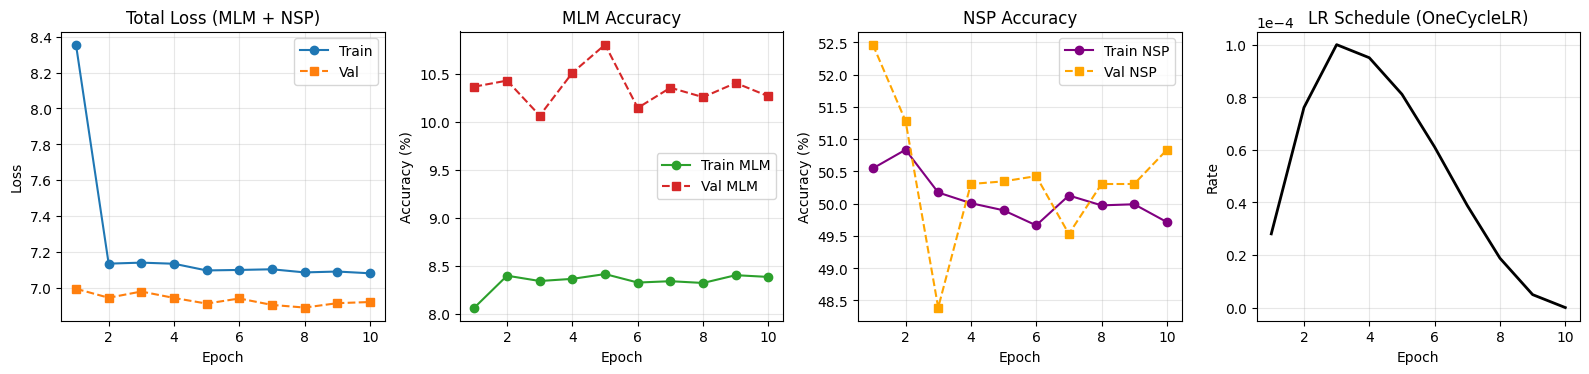

In [18]:
# ==========================================
# 3c. Plot Pre-training Curves
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
epochs = range(1, len(pretrain_history['train_loss']) + 1)

# 1. Total Loss (Train vs Val)
axes[0].plot(epochs, pretrain_history['train_loss'], 'o-', label='Train', color='#1f77b4')
axes[0].plot(epochs, pretrain_history['val_loss'], 's--', label='Val', color='#ff7f0e')
axes[0].set_title('Total Loss (MLM + NSP)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. MLM Accuracy (Train vs Val)
axes[1].plot(epochs, [a*100 for a in pretrain_history['train_mlm_acc']], 'o-', label='Train MLM', color='#2ca02c')
axes[1].plot(epochs, [a*100 for a in pretrain_history['val_mlm_acc']], 's--', label='Val MLM', color='#d62728')
axes[1].set_title('MLM Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. NSP Accuracy (Train vs Val)
axes[2].plot(epochs, [a*100 for a in pretrain_history['train_nsp_acc']], 'o-', label='Train NSP', color='purple')
axes[2].plot(epochs, [a*100 for a in pretrain_history['val_nsp_acc']], 's--', label='Val NSP', color='orange')
axes[2].set_title('NSP Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[3].plot(epochs, pretrain_history['lrs'], label='LR', color='black', linewidth=2)
axes[3].set_title('LR Schedule (OneCycleLR)')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Rate')
axes[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# 4. Phase 2 — Fine-tuning on SST-2 (Sentiment Analysis)

We freeze-then-unfreeze the pre-trained BERT encoder, add a simple classification head
on top of the `[CLS]` token, and fine-tune on SST-2 (binary: positive/negative).

---


In [19]:
# ==========================================
# 4a. SST-2 Dataset
# ==========================================

class SST2Dataset(Dataset):
    """Wraps SST-2 for BERT: [CLS] sentence [SEP], segment_ids, label."""
    def __init__(self, hf_dataset, vocab, max_len=128):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item['sentence']
        label = item['label'] if item['label'] != -1 else 0

        # Tokenize & encode
        tokens = tokenizer(text)
        token_ids = [vocab.get(t, UNK_IDX) for t in tokens]

        # [CLS] sentence [SEP]
        token_ids = [CLS_IDX] + token_ids[:self.max_len - 2] + [SEP_IDX]
        segment_ids = [0] * len(token_ids)  # Single sentence → all segment 0

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(segment_ids, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )


def sst2_collate_fn(batch):
    tokens, segments, labels = zip(*batch)
    tokens = pad_sequence(tokens, batch_first=True, padding_value=PAD_IDX)
    segments = pad_sequence(segments, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return tokens, segments, labels


# Build DataLoaders
sst2_train_ds = SST2Dataset(sst2_dataset['train'], vocab, max_len=MAX_LEN)
sst2_val_ds = SST2Dataset(sst2_dataset['validation'], vocab, max_len=MAX_LEN)
sst2_test_ds = SST2Dataset(sst2_dataset['test'], vocab, max_len=MAX_LEN)

sst2_train_loader = DataLoader(
    sst2_train_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True, collate_fn=sst2_collate_fn
)
sst2_val_loader = DataLoader(
    sst2_val_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False, collate_fn=sst2_collate_fn
)
sst2_test_loader = DataLoader(
    sst2_test_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False, collate_fn=sst2_collate_fn
)

print(f"SST-2 Train batches: {len(sst2_train_loader)}, Val batches: {len(sst2_val_loader)}, Test batches: {len(sst2_test_loader)}")

SST-2 Train batches: 2105, Val batches: 28, Test batches: 57


In [20]:
# Quick Robust Check
test_labels = next(iter(sst2_test_loader))[2]
print(f"Test Label Check: {test_labels.min().item()} to {test_labels.max().item()} (Should be 0 or 1)")

Test Label Check: 0 to 0 (Should be 0 or 1)


In [21]:
# ==========================================
# 4b. BERT Classifier (Fine-tuning wrapper)
# ==========================================

class BERTClassifier(nn.Module):
    """
    Takes a pre-trained BERT encoder and adds a classification head.
    Classification is done via the [CLS] token's hidden state.
    """
    def __init__(self, bert_model, d_model, num_classes, dropout=0.1):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, input_ids, segment_ids):
        # Get encoder hidden states (reuse BERT's encode method, NOT the pre-training heads)
        hidden = self.bert.encode(input_ids, segment_ids)
        cls_output = hidden[:, 0, :]  # [CLS] token
        return self.classifier(cls_output)


In [26]:
# ==========================================
# 4c. Fine-tuning Training & Evaluation Loop
# ==========================================

def evaluate_classifier(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for tokens, segments, labels in data_loader:
            tokens, segments, labels = tokens.to(device), segments.to(device), labels.to(device)
            logits = model(tokens, segments)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    return avg_loss, acc, f1, all_preds, all_labels


# def evaluate_classifier(model, data_loader, criterion, device):
#     model.eval()
#     total_loss = 0.0
#     all_preds, all_labels = [], []

#     # Get metadata for robust checking
#     vocab_limit = model.bert.embedding.tok_embed.num_embeddings
#     pos_limit = model.bert.embedding.pos_embed.num_embeddings

#     with torch.no_grad():
#         for batch_idx, (tokens, segments, labels) in enumerate(data_loader):

#             # --- ROBUST PRE-FLIGHT CHECKS ---
#             # 1. Check for IndexErrors in Embeddings
#             if tokens.max() >= vocab_limit:
#                 raise IndexError(f"Batch {batch_idx}: Token ID {tokens.max()} exceeds vocab size {vocab_limit}.")

#             # 2. Check for Positional Encoding overflow
#             if tokens.size(1) > pos_limit:
#                 raise IndexError(f"Batch {batch_idx}: Sequence length {tokens.size(1)} exceeds MAX_LEN {pos_limit}.")

#             # 3. Check for Label range (SST-2 expects 0 or 1)
#             if labels.max() > 1 or labels.min() < 0:
#                 raise ValueError(f"Batch {batch_idx}: Invalid labels found. Expected [0, 1], got range [{labels.min()}, {labels.max()}].")

#             # Move to device only after checks pass
#             tokens, segments, labels = tokens.to(device), segments.to(device), labels.to(device)

#             logits = model(tokens, segments)
#             loss = criterion(logits, labels)

#             total_loss += loss.item() * labels.size(0)
#             preds = logits.argmax(dim=-1)
#             all_preds.extend(preds.cpu().tolist())
#             all_labels.extend(labels.cpu().tolist())

#     avg_loss = total_loss / len(all_labels)
#     acc = accuracy_score(all_labels, all_preds)
#     f1 = f1_score(all_labels, all_preds, average='binary')
#     return avg_loss, acc, f1, all_preds, all_labels


def finetune_bert(model, train_loader, val_loader, num_epochs, lr, device, patience=3):
    """
    Fine-tune BERT classifier on SST-2.
    Uses AdamW with linear warmup (standard BERT fine-tuning recipe).
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    )
    criterion = nn.CrossEntropyLoss()

    use_amp = (device.type == 'cuda')
    scaler = GradScaler('cuda', enabled=use_amp)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lrs': []}
    best_val_acc = 0.0
    epochs_no_improve = 0
    start_time = time.time()

    print(f"Fine-tuning BERT on SST-2 ({device})...")
    print(f"Epochs: {num_epochs} | LR: {lr} | Patience: {patience}")
    print("-" * 80)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for tokens, segments, labels in train_loader:
            tokens, segments, labels = tokens.to(device), segments.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                logits = model(tokens, segments)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()

        # Evaluate
        avg_train_loss = train_loss / len(train_loader)
        val_loss, val_acc, val_f1, _, _ = evaluate_classifier(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lrs'].append(current_lr)

        # Early stopping on accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_bert_sst2.pth')
            epochs_no_improve = 0
            status = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status = f" (No improve: {epochs_no_improve}/{patience})"

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Loss (T/V): {avg_train_loss:.4f} / {val_loss:.4f} | "
              f"Acc: {val_acc*100:.2f}% | F1: {val_f1*100:.2f}% | "
              f"LR: {current_lr:.2e}{status}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f"\nFine-tuning complete! Total time: {(time.time()-start_time)/60:.1f} min")
    print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")
    model.load_state_dict(torch.load('best_bert_sst2.pth'))
    return history


In [27]:
# ==========================================
# 4d. Initialize & Fine-tune
# ==========================================

set_all_seeds(RANDOM_SEED)

# Load pre-trained weights
bert_model.load_state_dict(torch.load('bert_pretrained.pth', map_location=DEVICE))

# Wrap with classification head
classifier = BERTClassifier(
    bert_model=bert_model,
    d_model=D_MODEL,
    num_classes=2,  # SST-2: positive / negative
    dropout=DROPOUT
).to(DEVICE)

print(f"Classifier parameters: {sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}")


Classifier parameters: 102,302,228


In [28]:
# Run Fine-tuning
finetune_history = finetune_bert(
    classifier, sst2_train_loader, sst2_val_loader,
    num_epochs=FINETUNE_EPOCHS,
    lr=FINETUNE_LR,
    device=DEVICE,
    patience=PATIENCE
)


Fine-tuning BERT on SST-2 (cuda)...
Epochs: 10 | LR: 2e-05 | Patience: 3
--------------------------------------------------------------------------------
Epoch 01/10 | Loss (T/V): 0.6871 / 0.6271 | Acc: 65.25% | F1: 69.79% | LR: 5.60e-06 * (Saved Best)
Epoch 02/10 | Loss (T/V): 0.5058 / 0.5215 | Acc: 75.23% | F1: 72.16% | LR: 1.52e-05 * (Saved Best)
Epoch 03/10 | Loss (T/V): 0.3971 / 0.6325 | Acc: 75.69% | F1: 78.46% | LR: 2.00e-05 * (Saved Best)
Epoch 04/10 | Loss (T/V): 0.3414 / 0.6253 | Acc: 76.72% | F1: 76.69% | LR: 1.90e-05 * (Saved Best)
Epoch 05/10 | Loss (T/V): 0.2920 / 0.5835 | Acc: 77.52% | F1: 76.89% | LR: 1.62e-05 * (Saved Best)
Epoch 06/10 | Loss (T/V): 0.2531 / 0.7890 | Acc: 75.80% | F1: 76.63% | LR: 1.22e-05 (No improve: 1/3)
Epoch 07/10 | Loss (T/V): 0.2211 / 0.8310 | Acc: 75.34% | F1: 76.24% | LR: 7.77e-06 (No improve: 2/3)
Epoch 08/10 | Loss (T/V): 0.1975 / 1.0033 | Acc: 76.15% | F1: 77.54% | LR: 3.76e-06 (No improve: 3/3)

Early stopping triggered.

Fine-tuning compl

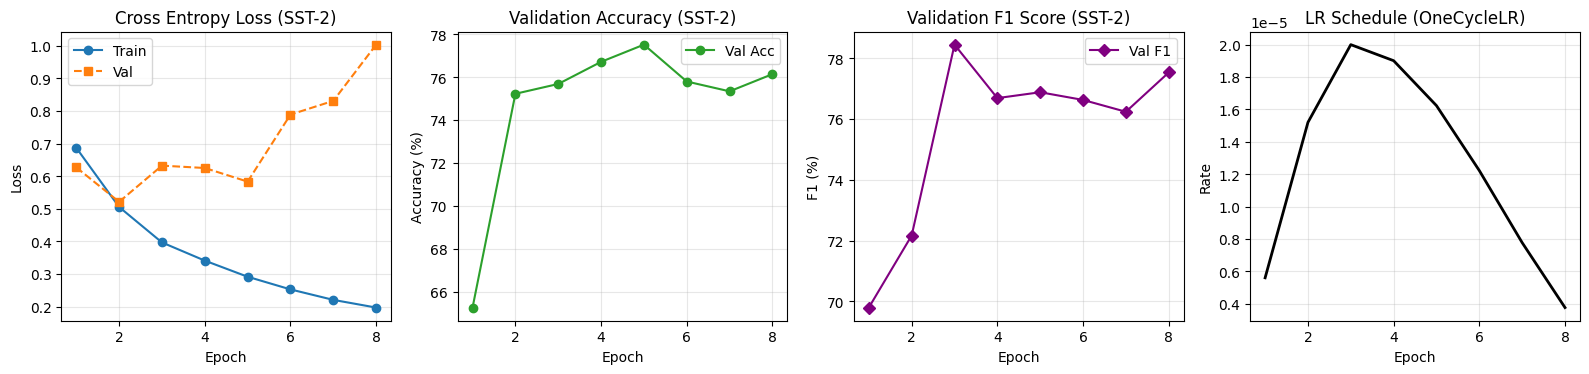

In [29]:
# ==========================================
# 4e. Plot Fine-tuning Curves
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
epochs = range(1, len(finetune_history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, finetune_history['train_loss'], 'o-', label='Train', color='#1f77b4')
axes[0].plot(epochs, finetune_history['val_loss'], 's--', label='Val', color='#ff7f0e')
axes[0].set_title('Cross Entropy Loss (SST-2)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a*100 for a in finetune_history['val_acc']], 'o-', label='Val Acc', color='#2ca02c')
axes[1].set_title('Validation Accuracy (SST-2)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1
axes[2].plot(epochs, [f*100 for f in finetune_history['val_f1']], 'D-', label='Val F1', color='purple')
axes[2].set_title('Validation F1 Score (SST-2)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[3].plot(epochs, finetune_history['lrs'], label='LR', color='black', linewidth=2)
axes[3].set_title('LR Schedule (OneCycleLR)')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Rate')
axes[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# 5. Final Evaluation & Audit

---

In [30]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
print("CUDA_LAUNCH_BLOCKING is set to 1 for detailed error messages.")

# ==========================================
# 5a. Full Eval Report
# ==========================================

criterion = nn.CrossEntropyLoss()
val_loss, val_acc, val_f1, all_preds, all_labels = evaluate_classifier(
    classifier, sst2_val_loader, criterion, DEVICE
)

print("=" * 60)
print("           FINAL SST-2 VALIDATION AUDIT           ")
print("=" * 60)
print(f"  Loss:     {val_loss:.4f}")
print(f"  Accuracy: {val_acc*100:.2f}%")
print(f"  F1 Score: {val_f1*100:.2f}%")
print("=" * 60)

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))


CUDA_LAUNCH_BLOCKING is set to 1 for detailed error messages.
           FINAL SST-2 VALIDATION AUDIT           
  Loss:     0.5835
  Accuracy: 77.52%
  F1 Score: 76.89%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.82      0.78       428
    Positive       0.81      0.73      0.77       444

    accuracy                           0.78       872
   macro avg       0.78      0.78      0.78       872
weighted avg       0.78      0.78      0.77       872



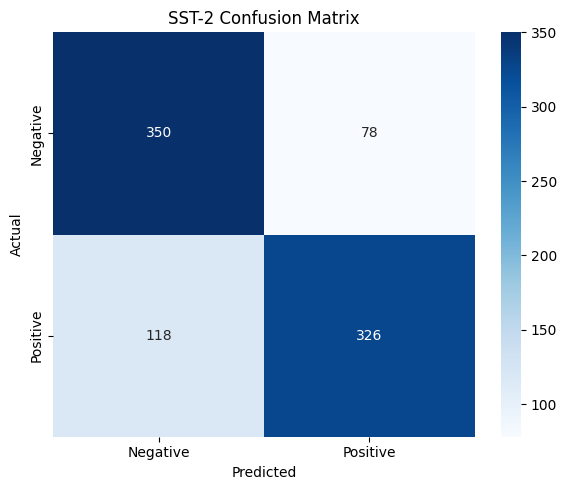

In [31]:
# ==========================================
# 5b. Confusion Matrix
# ==========================================

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SST-2 Confusion Matrix')
plt.tight_layout()
plt.show()


---

#6. Inference

---

In [33]:
# ==========================================
# 6. Sentiment Prediction
# ==========================================

def predict_classifier(model, data_loader, device):
    """Robust prediction for unlabeled sets (like SST-2 Test)."""
    model.eval()
    all_preds = []

    with torch.no_grad():
        for tokens, segments, _ in data_loader: # We ignore the third item (label)
            tokens, segments = tokens.to(device), segments.to(device)
            logits = model(tokens, segments)
            preds = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())

    return all_preds


# Run on Test (This gives you the raw predictions)
test_predictions = predict_classifier(classifier, sst2_test_loader, DEVICE)

print(f"Generated {len(test_predictions)} predictions for the test set.")


Generated 1821 predictions for the test set.


In [34]:
def sanity_check_test_samples(dataset, preds, n=10):
    indices = random.sample(range(len(dataset)), n)
    label_map = {0: "Negative", 1: "Positive"}

    print(f"{'PREDICTION':<12} | {'TEXT'}")
    print("-" * 50)
    for i in indices:
        text = dataset[i]['sentence']
        pred_label = label_map[preds[i]]
        print(f"{pred_label:<12} | {text[:80]}...")

# Run it
sanity_check_test_samples(sst2_dataset['test'], test_predictions)


PREDICTION   | TEXT
--------------------------------------------------
Positive     | for all its failed connections , divine secrets of the ya-ya sisterhood is nurtu...
Positive     | sits uneasily as a horror picture ... but finds surprising depth in its look at ...
Positive     | this cheery , down-to-earth film is warm with the cozy feeling of relaxing aroun...
Negative     | undercover brother does n't go far enough ....
Negative     | stars matthew perry and elizabeth hurley illicit more than a chuckle , and more ...
Negative     | home alone goes hollywood , a funny premise until the kids start pulling off stu...
Negative     | not every animated film from disney will become a classic , but forgive me if i ...
Negative     | but like bruce springsteen 's gone-to-pot asbury park , new jersey , this sad-sa...
Positive     | there are films that try the patience of even the most cinema-besotted critic --...
Positive     | flotsam in the sea of moviemaking , not big enough for us to

In [35]:
counts = Counter(test_predictions)
print(f"Test Set Distribution: {counts}")


Test Set Distribution: Counter({0: 982, 1: 839})


In [37]:
# ==========================================
# 5c. Qualitative Sentiment Predictions
# ==========================================

def predict_sentiment(text, model, vocab, device, max_len=128):
    """Run inference on a single sentence."""
    model.eval()
    tokens = tokenizer(text)
    token_ids = [CLS_IDX] + [vocab.get(t, UNK_IDX) for t in tokens][:max_len-2] + [SEP_IDX]
    segment_ids = [0] * len(token_ids)

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    seg_ids = torch.tensor([segment_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids, seg_ids)
        probs = F.softmax(logits, dim=-1)
        pred = logits.argmax(dim=-1).item()

    label = "Positive" if pred == 1 else "Negative"
    confidence = probs[0, pred].item()
    return label, confidence


# Test sentences
test_sentences = [
    "This movie was absolutely wonderful and a delight to watch.",
    "A terrible waste of time, poorly written and badly acted.",
    "The food was okay, nothing special but not bad either.",
    "An incredible performance that moved me to tears.",
    "I was bored out of my mind during this awful film.",
    "A solid effort with great cinematography and decent acting.",
    "The worst experience I have ever had at a restaurant.",
    "Absolutely brilliant, a masterpiece of modern cinema.",
    "This transformer implementation from scratch is surprisingly efficient and robust!"
]

print(f"{'Sentence':<60} | {'Prediction':<10} | {'Confidence'}")
print("-" * 90)
for sent in test_sentences:
    label, conf = predict_sentiment(sent, classifier, vocab, DEVICE)
    marker = "★" if conf > 0.90 else " "
    display = sent[:57] + "..." if len(sent) > 57 else sent
    print(f"{display:<60} | {label:<10} | {conf:.2%} {marker}")


Sentence                                                     | Prediction | Confidence
------------------------------------------------------------------------------------------
This movie was absolutely wonderful and a delight to watc... | Positive   | 98.04% ★
A terrible waste of time, poorly written and badly acted.    | Negative   | 95.33% ★
The food was okay, nothing special but not bad either.       | Negative   | 94.59% ★
An incredible performance that moved me to tears.            | Positive   | 98.77% ★
I was bored out of my mind during this awful film.           | Negative   | 92.37% ★
A solid effort with great cinematography and decent actin... | Positive   | 98.91% ★
The worst experience I have ever had at a restaurant.        | Negative   | 94.97% ★
Absolutely brilliant, a masterpiece of modern cinema.        | Positive   | 98.34% ★
This transformer implementation from scratch is surprisin... | Positive   | 98.64% ★


---
# Summary

---

In this notebook, I implemented **BERT** from scratch, evolving the Transformer encoder from the
previous *"Attention Is All You Need"* notebook into a bidirectional, self-supervised model.

**Phase 1 (Pre-training):** The model was pre-trained on WikiText-2 with two objectives:
- **MLM (Masked Language Modeling):** Predict randomly masked tokens from bidirectional context.
- **NSP (Next Sentence Prediction):** Classify whether sentence B follows sentence A.

**Phase 2 (Fine-tuning):** The pre-trained encoder was fine-tuned on **SST-2** (GLUE) for
binary sentiment classification, using only the `[CLS]` token representation.

<br>

### Architectural Evolution Path

| Step | Architecture | Key Innovation | Primary Task |
| :--- | :--- | :--- | :--- |
| 1 | Seq2Seq (LSTM/GRU) | Recurrent encoding | Translation |
| 2 | Seq2Seq + Attention | Dynamic alignment | Translation |
| 3 | **Transformer** | Self-Attention / Parallelism | Translation |
| 4 | **BERT** (this notebook) | Bidirectional + Self-Supervised | **Classification** |

---


In [39]:
%watermark -iv


datasets  : 4.0.0
matplotlib: 3.10.0
numpy     : 2.0.2
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.6.1
torch     : 2.10.0+cu128
torchinfo : 1.8.0

